### Importar Librerías

In [2]:
!pip install opencv-python matplotlib numpy scikit-image ipywidgets

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ------------------ --------------------- 18.4/40.2 MB 90.8 MB/s eta 0:00:01
   ---------------------------------------  39.6/40.2 MB 94.1 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 93.2 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 60.9 MB/s  0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import color

### Cargar imagen

(np.float64(-0.5), np.float64(442.5), np.float64(423.5), np.float64(-0.5))

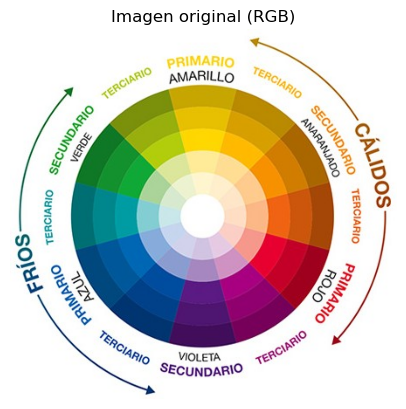

In [18]:
# Cargar imagen
image = cv2.imread("imagen1.jpg")

# Convertir de BGR (OpenCV) a RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Imagen original (RGB)")
plt.axis("off")

### Convertir RGB → HSV

HSV separa:

- Hue = tono

- Saturation = intensidad del color

- Value = brillo

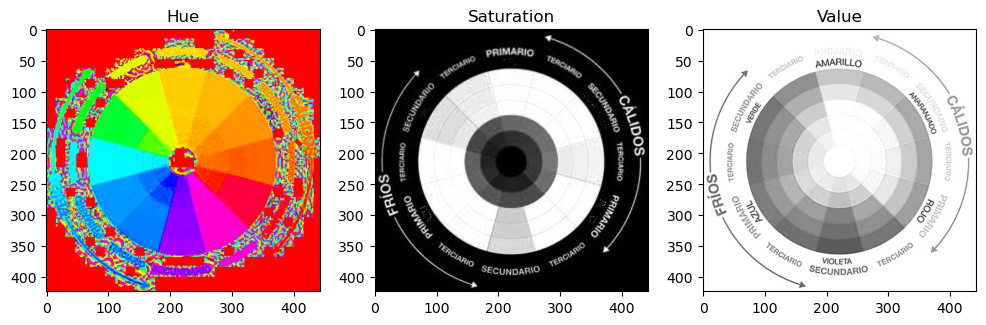

In [19]:
hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(h, cmap='hsv')
plt.title("Hue")

plt.subplot(1,3,2)
plt.imshow(s, cmap='gray')
plt.title("Saturation")

plt.subplot(1,3,3)
plt.imshow(v, cmap='gray')
plt.title("Value")

plt.show()

### Convertir RGB → CIE Lab

El espacio CIE Lab está diseñado para aproximarse a la percepción humana.

Componentes:

- L = luminosidad

- a = verde ↔ rojo

- b = azul ↔ amarillo

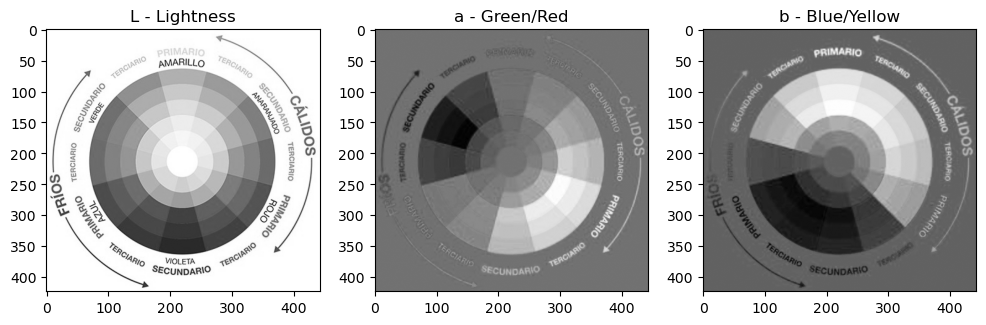

In [20]:
lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)

l, a, b = cv2.split(lab)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(l, cmap='gray')
plt.title("L - Lightness")

plt.subplot(1,3,2)
plt.imshow(a, cmap='gray')
plt.title("a - Green/Red")

plt.subplot(1,3,3)
plt.imshow(b, cmap='gray')
plt.title("b - Blue/Yellow")

plt.show()

### Simulación de Daltonismo

Simulación simple usando matrices de transformación.

Protanopía (deficiencia en rojo)

In [21]:
def protanopia_simulation(img):

    matrix = np.array([
        [0.56667, 0.43333, 0],
        [0.55833, 0.44167, 0],
        [0,       0.24167, 0.75833]
    ])

    img = img / 255.0
    sim = img @ matrix.T
    sim = np.clip(sim,0,1)

    return (sim * 255).astype(np.uint8)

Deuteranopía (deficiencia en verde)

In [22]:
def deuteranopia_simulation(img):

    matrix = np.array([
        [0.625, 0.375, 0],
        [0.70,  0.30,  0],
        [0,     0.30,  0.70]
    ])

    img = img / 255.0
    sim = img @ matrix.T
    sim = np.clip(sim,0,1)

    return (sim * 255).astype(np.uint8)

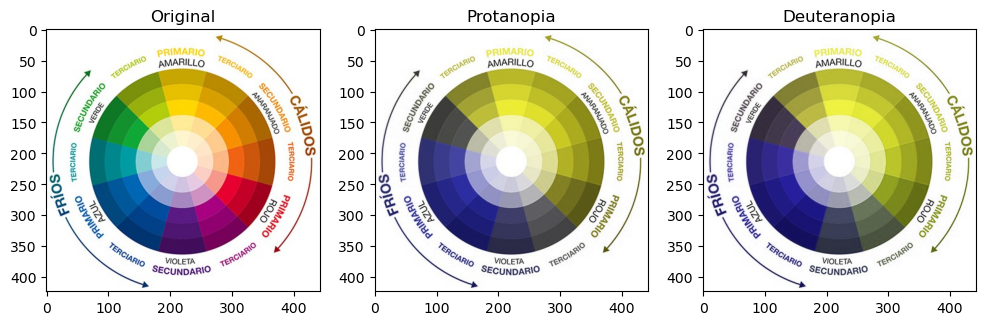

In [23]:
protanopia = protanopia_simulation(image_rgb)
deuteranopia = deuteranopia_simulation(image_rgb)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(protanopia)
plt.title("Protanopia")

plt.subplot(1,3,3)
plt.imshow(deuteranopia)
plt.title("Deuteranopia")

plt.show()

### Simular baja iluminación

Reduciendo el brillo.

In [10]:
def reduce_brightness(img, factor=0.4):

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    h, s, v = cv2.split(hsv)

    v = (v * factor).astype(np.uint8)

    hsv_dark = cv2.merge([h,s,v])

    return cv2.cvtColor(hsv_dark, cv2.COLOR_HSV2RGB)

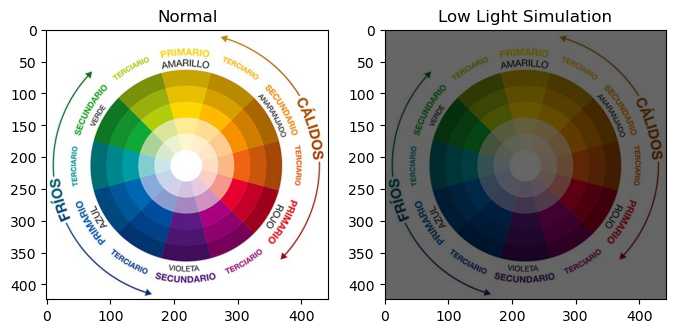

In [24]:
low_light = reduce_brightness(image_rgb)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Normal")

plt.subplot(1,2,2)
plt.imshow(low_light)
plt.title("Low Light Simulation")

plt.show()

### Filtros de color
Temperatura cálida

In [12]:
def warm_filter(img):

    img = img.astype(float)

    img[:,:,0] *= 1.1
    img[:,:,1] *= 1.05

    img = np.clip(img,0,255)

    return img.astype(np.uint8)

Temperatura fría

In [13]:
def cool_filter(img):

    img = img.astype(float)

    img[:,:,2] *= 1.2

    img = np.clip(img,0,255)

    return img.astype(np.uint8)

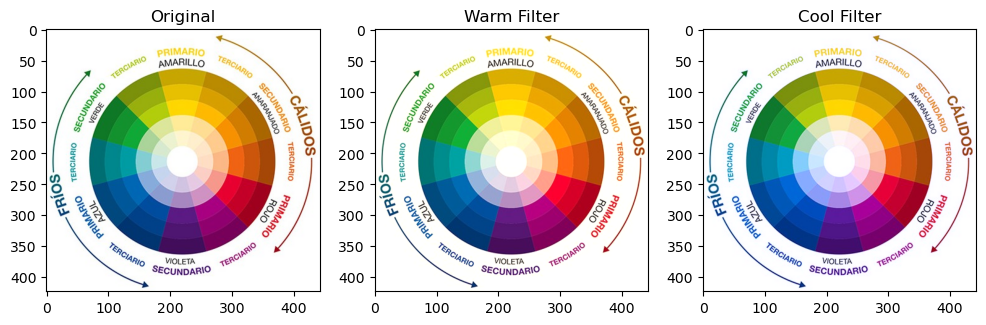

In [25]:
warm = warm_filter(image_rgb)
cool = cool_filter(image_rgb)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(warm)
plt.title("Warm Filter")

plt.subplot(1,3,3)
plt.imshow(cool)
plt.title("Cool Filter")

plt.show()

### Filtro monocromático

(np.float64(-0.5), np.float64(442.5), np.float64(423.5), np.float64(-0.5))

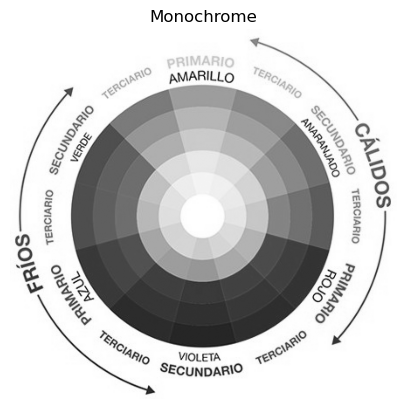

In [26]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Monochrome")
plt.axis("off")

### BONUS — Alternar modelos

Esto cumple el bonus del taller.

In [16]:
def show_mode(mode):

    if mode == "rgb":
        plt.imshow(image_rgb)

    elif mode == "hsv":
        plt.imshow(hsv)

    elif mode == "lab":
        plt.imshow(lab)

    elif mode == "protanopia":
        plt.imshow(protanopia)

    elif mode == "deuteranopia":
        plt.imshow(deuteranopia)

    plt.title(mode)
    plt.axis("off")

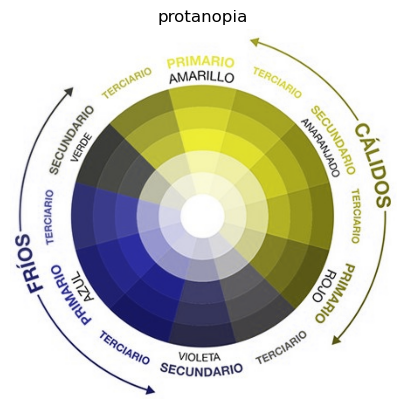

In [27]:
show_mode("protanopia")